# Drive noise induced phase decoherence validation

### Author: Daniel Gonçalves Benvenutti - UNICAMP
30 May 2025

Qutip Version: 5.1.1





In [1]:
# to use in google colab
!pip install qutip

In [75]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import lsim, TransferFunction

## Simulation Parameters



In [204]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]
Ed=0.01*2*np.pi #driving energy [GHz.rad]

pi_pulse=np.pi/Ed #[ns]
print(f"pi pulse={pi_pulse:.2e}")

T1=2000 #relaxation time [ns]
T2=1000 #dephasing time [ns]

# (T2 must be T2<=2T1)
if T2>2*T1:
  raise Exception("T2 must be T2<=2T1")

# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
    # time independant hamiltonian (normalized by wq)
    if Ed_t is None:
        return -0.5*wq*sz/wq
    # time dependant non interpolated drive signal hamiltonian (here Ed_t is a function/lambda)
    if tlist is None:
        return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]]) 
    # time dependant hamiltonian interpolated drive (here Ed_t is an array with amplitudes)
    # [time independant part, [operator,time dependant operator amplitude]]
    # [qubit, [drive]]
    return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
    if T2 is None:
        return [np.sqrt(1/T1/wq)*sm]
    gamma_phi=1/T2-1/2/T1 #pure dephasing constant
    return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
#return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms



pi pulse=5.00e+01


## Noise generator functions from [stackoverflow](https://stackoverflow.com/questions/67085963/generate-colors-of-noise-in-python).

In [136]:
def noise_psd(tlist, psd = lambda f: 1):
    N=len(tlist)
    X_white = np.fft.rfft(np.random.randn(N));
    S = psd( np.fft.rfftfreq(N, d=tlist[1]-tlist[0]) )
    # Normalize S
    S = S / np.sqrt(np.mean(S**2))
    X_shaped = X_white * S;
    return np.fft.irfft(X_shaped, n=N);

def PSDGenerator(f):
    return lambda N: noise_psd(N, f)

@PSDGenerator
def white_noise(f):
    return 1;

@PSDGenerator
def blue_noise(f):
    return np.sqrt(f);

@PSDGenerator
def violet_noise(f):
    return f;

@PSDGenerator
def brownian_noise(f):
    return 1/np.where(f == 0, float('inf'), f)

@PSDGenerator
def pink_noise(f):
    return 1/np.where(f == 0, float('inf'), np.sqrt(f))

# Filters

In [134]:
def band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    # n stages
    
    #Y(s)=H(s)X(s)
    wc=2*np.pi*fc
    w0=2*np.pi*f0

    #multiples numerator and denominator polynomials of the filter transfer function n times
    num,den=[1],[1]
    for _ in range( n):
        num = np.polymul(num, [1, 0, w0**2])
        den = np.polymul(den, [1, wc, w0**2])
    #system H(s)^n 
    tf=TransferFunction(num,den)
    
    #y(t)
    _, y_t, _ = lsim(tf, U=x_t, T=tlist)
    return y_t

def ideal_band_stop(tlist, x_t, f0=1,fc=1, n=1):
    # f0 central frequency [GHz]
    # fc bandwidth [GHz]
    X_s = np.fft.fft(x_t)
    
    # Calculate the corresponding frequencies
    freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
    
    Y_s = np.where( (np.abs(freq)>= f0-fc/2) & (np.abs(freq)<= f0+fc/2) ,0,X_s)
    
    # Normalize H_s
    #H_s = H_s / np.sqrt(np.mean(H_s**2))
    #Y_s = X_s * H_s
    
    return np.fft.ifft(Y_s)


In [143]:
tlist=np.linspace(0,500,int(500*3000/wq)) # ns
y=pink_noise(tlist)
drive_data=band_stop(tlist,y,fc=0.5,n=4)

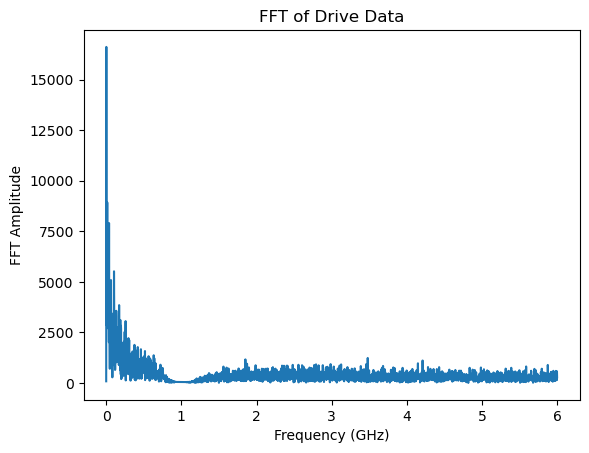

In [144]:
# Calculate the FFT
drive_fft = np.fft.fft(drive_data)

# Calculate the corresponding frequencies
freq = np.fft.fftfreq(len(tlist), d=tlist[1] - tlist[0])
middle=len(freq)//2
zoom=np.where((freq[:middle]>=0) & (freq[:middle]<=6))[0]
# Plot the FFT with proper frequency axis
plt.plot(freq[zoom], np.abs(drive_fft)[zoom])
plt.xlabel('Frequency (GHz)')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Drive Data')
plt.show()

# Plots

In [147]:
def ramsey_plot(T,exp, T2_guess=2*T1):
  # prompt: plot exp and t as a ramsey oscillation with a damped sine fit

  def damped_sine(t, amplitude, frequency, tau, phase, offset):
    return amplitude * np.exp( - t/tau) * np.sin(2 * np.pi * frequency * t + phase) + offset

  params, covariance = curve_fit(damped_sine, T, exp, p0=[0.5, 0.002, T2_guess, np.pi/2, 0.5])

  amplitude, frequency, decay_constant, phase, offset = params
  t=np.linspace(T[0],T[-1],len(T)*10)
  fitted_exp = damped_sine(t, amplitude, frequency, decay_constant, phase, offset)

  fig, axes = plt.subplots(1, 1, figsize=(10,6))
  axes.plot(T, exp, label='Simulated Data')
  axes.plot(t, fitted_exp, label='Damped Sine Fit')
  axes.set_xlabel('Time (ns)')
  axes.set_ylabel('Excitation expectation value')
  axes.set_title(f'Ramsey Oscillation with Damped Sine Fit $T_2^*$={params[2]*1e-3:.2f}$\mu s$')
  axes.legend()
  plt.show()
    
def echo_plot(T, exp, T2_guess=2*T1):
  # prompt: plot the t2 echo exp with T and an exponential upside down non oscillating fit with the time constant in the title of the graph

  # Assuming T and exp are defined from the previous code block (T2 echo simulation)

  def exponential_decay(t, amplitude, decay_constant, offset):
      return amplitude * np.exp(-t / decay_constant) + offset

  params, covariance = curve_fit(exponential_decay, T, exp, p0=[-1, T2_guess, 0.5])

  amplitude, decay_constant, offset = params
  t_fit = np.linspace(T[0], T[-1], 1000)
  fitted_exp = exponential_decay(t_fit, amplitude, decay_constant, offset)


  fig, axes = plt.subplots(1, 1, figsize=(10, 6))
  axes.plot(T/1000, exp, label='Simulated Data')
  axes.plot(t_fit/1000, fitted_exp, label='Exponential Fit')
  axes.set_xlabel('Time ($\mu $s)')
  axes.set_ylabel('Excitation expectation value')
  axes.set_title(f'T2 Echo with Exponential Fit, $T_2^{{echo}}$={2*decay_constant/1000:.2f}$\mu s$')
  axes.legend()
  plt.show()

# Simulation

In [289]:
class Noisy_T2:
    def __init__(self,Det, noise=None, hahn=False):
        
        self.Det=Det
        self.Ed=Ed
        self.T1=T1
        self.T2=None
        self.noise=noise
        self.hahn=hahn # True if simulation is a Hahn echo and not a Ramsey oscillation
        self.atol=1e-10
        self.rtol=1e-8

        self.qubit_period=2*np.pi/wq
        # Times for the free evolution with noise
        self.free_step=self.qubit_period/4 # ns
        self.pulse_step=self.qubit_period/4 # ns
        self.noise_step=self.qubit_period/10 # ns
        
        # initial state
        self.psi0=qtp.basis(2,0)

        # initializes with the first pulse        
        self.start()
        
    def start(self):
        # You are supposed to rerun this everytime you change any simulation parameter like T1 or T2 that appears here
        
        # time values for the time dependant simulation during excitation
        # The time dependant part of the simulation is usually a bottleneck
        # less points doesn't necessarily means less time/work
        self.pi_pulse=np.pi/self.Ed # [ns]

        
        #drive parameters
        wd=(wq+self.Det*2*np.pi)/wq # [rad.GHz]
        self.pure_drive=lambda t: self.Ed*(np.sin(wd*t)) # [rad.GHz]

        # dictionary with simulation options
        # for T2 simulations we need higher numerical precision
        # so we set atol and rtol that limit the (estimated) error
        # per integration step to be smaller
        self.options={"store_final_state":True,"nsteps":10000, "atol":self.atol,"rtol":self.rtol}

        # We put here in the init since it's the same for all runs
        # pi/2 pulse simulation with time dependant hamiltonian
        # it just simulates an excitation drive and returns the final state in the res
        self.start, self.start_shift = self.pulse_evolve(self.psi0, 0, self.pi_pulse/2)


    def pulse_evolve(self,psi, shift, period):
        step = self.pulse_step
        t = shift + np.arange( 0, period+step, step ) # [ns]
        res = qtp.mesolve( H(wq,self.pure_drive,None), psi, wq*t, c_ops(self.T1,self.T2), options=self.options )
        # shift to keep the phase consistent
        shift += pulse_vec[-1]
        return res, shift


        
    def free_evolve(self, psi, shift, T):
        t = shift + np.arange(0,T+self.free_step,self.free_step) # [ns]
        noise_data = None
        tlist = None
        if self.noise is not None: #generates noise
            tlist=shift+np.arange(0,T+1,self.noise_step) # [ns]
            noise_data=noise(tlist) # [rad.GHz]
        #Free evolution simulation with(out) noise
        res=qtp.mesolve(H(wq,noise_data,tlist), psi ,wq*t, c_ops(self.T1,self.T2), options=self.options)
        shift+=t[-1]
        return res,shift

    def run(self,T):
        # Ramsey/Hahn echo simulation with interrogation time T in [ns] and detuning Det in [GHz]
        
        shift=self.start_shift
        res=self.start
        # for T=0 or smaller than step not to throw an error
        if T>=self.free_step:
           res, shift = self.free_evolve(res.final_state, shift, T)

        # additional steps for the Hahn echo procedure
        if self.hahn:
            res, shift = self.pulse_evolve(res.final_state, shift, self.pi_pulse)
            # for T=0 or smaller than step not to throw an error
            if T>=self.free_step:
                  res, shift = self.free_evolve(res.final_state, shift, T)
            
        res, shift = self.pulse_evolve(res.final_state, shift, self.pi_pulse/2)    
        # return excitation expected value of the final state like a measurement
        return qtp.expect(n,res.final_state)

In [ ]:
T=np.linspace(0,4000,64) #ns
def noise(tlist):
    return 20*Ed*band_stop(tlist,white_noise(tlist),f0=wq/2/np.pi, fc=1,n=3)
exp1=Noisy_T2(0.002,noise=noise)

def wrap(T):
    return exp1.run(T)
data=list(qtp.parallel_map(wrap,T,progress_bar=True))
ramsey_plot(T,data)

10.9%. Run time:   5.11s. Est. time left: 00:00:00:41
20.3%. Run time:  13.53s. Est. time left: 00:00:00:53
31.2%. Run time:  30.56s. Est. time left: 00:00:01:07
40.6%. Run time:  46.26s. Est. time left: 00:00:01:07
50.0%. Run time:  73.44s. Est. time left: 00:00:01:13
60.9%. Run time: 104.78s. Est. time left: 00:00:01:07
70.3%. Run time: 137.01s. Est. time left: 00:00:00:57


In [ ]:
T=np.linspace(0,4000,64) #ns

exp1=Noisy_T2(0.002)

def wrap(T):
    return exp1.run(T)
data=list(qtp.parallel_map(wrap,T,progress_bar=True))
ramsey_plot(T,data)